In [ ]:
import pandas as pd
df1 = pd.read_csv("clients.csv")
df1.head()

,client id,client type,first name,last name,date of birth,gender,country,region,acquisition purpose,satisfaction score,loan applied,referral channel
0,C0001,Individual,Kareem,Liu,05-11-68,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-59,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [ ]:
df1 = pd.read_csv("properties.csv")
df1.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-24,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-24,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-24,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-24,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-24,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [ ]:
df1.shape

(10000, 9)

In [ ]:
df1['tower_number'].unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20])

In [ ]:
df2 = df1.drop(['tower_number','transaction_date','client_ref','listing_status'],axis='columns')
df2.head()

,listing_id,unit_category,unit_number,floor_area_sqft,sale_price
0,1012,Apartment,12,1160.36,"$300,385.62"
1,1015,Apartment,15,782.25,"$208,930.81"
2,1021,Apartment,21,756.21,"$218,585.92"
3,1030,Apartment,30,743.09,"$246,172.68"
4,2016,Apartment,16,701.66,"$212,265.67"


# **Data Cleaning**

In [ ]:
df2.isnull().sum()

,0
listing_id,0
unit_category,0
unit_number,0
floor_area_sqft,0
sale_price,0


In [ ]:
df2.drop_duplicates(inplace=True)

In [ ]:
from datetime import datetime
import pandas as pd

current_year = datetime.now().year

df_clients = pd.read_csv("clients.csv")

def parse_date_of_birth(date_str):
    try:
        return pd.to_datetime(date_str, format='%m-%d-%y') # Try MM-DD-YY
    except ValueError:
        try:
            return pd.to_datetime(date_str, format='%m/%d/%Y') # Try MM/DD/YYYY
        except ValueError:
            return pd.NaT # Return Not a Time for unparseable dates

df_clients['parsed_dob'] = df_clients['date of birth'].apply(parse_date_of_birth)
df_clients['age'] = current_year - df_clients['parsed_dob'].dt.year

In [ ]:
df_clients.drop('date of birth', axis=1, inplace=True, errors='ignore')

# **Exploratory Data Analysis (EDA)**

Buyer Type Distribution

<Axes: xlabel='client type', ylabel='count'>

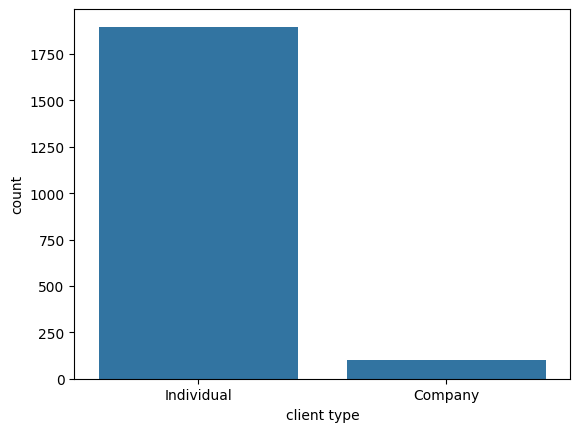

In [ ]:
import seaborn as sns
sns.countplot(x='client type', data=df_clients)

Acquisition Purpose

<Axes: xlabel='acquisition purpose', ylabel='count'>

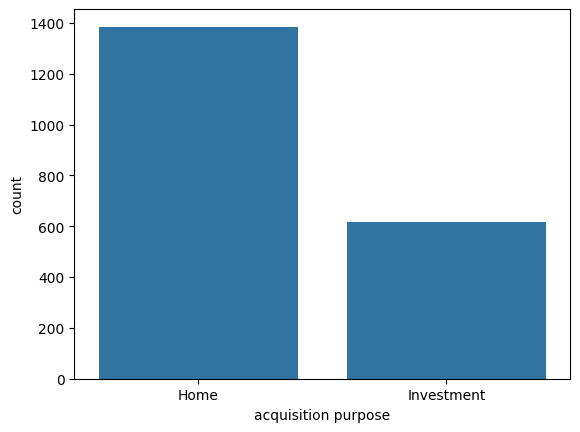

In [ ]:
sns.countplot(x='acquisition purpose', data=df_clients)

Loan Analysis

<Axes: xlabel='loan applied', ylabel='count'>

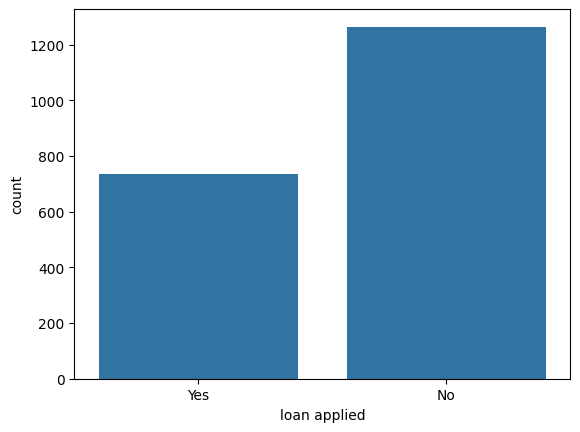

In [ ]:
sns.countplot(x='loan applied', data=df_clients)

Geographic Analysis

<Axes: xlabel='count', ylabel='country'>

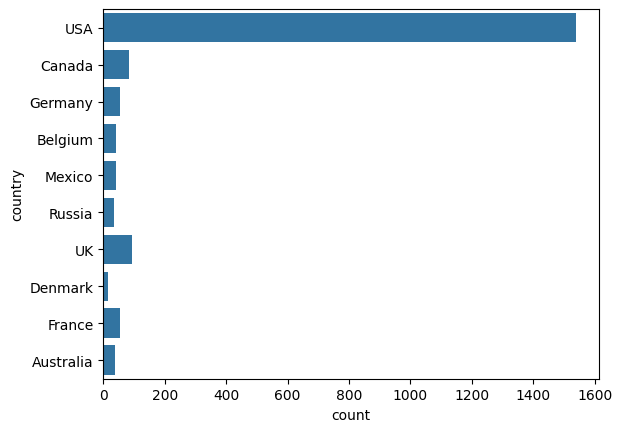

In [ ]:
sns.countplot(y='country', data=df_clients)

Satisfaction Analysis

<Axes: xlabel='client type', ylabel='satisfaction score'>

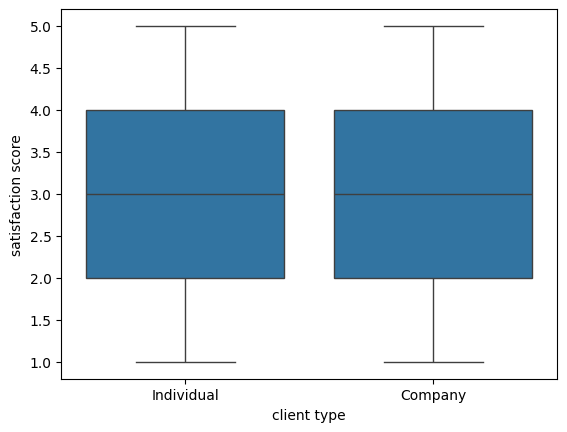

In [ ]:
sns.boxplot(x='client type', y='satisfaction score', data=df_clients)

# **Feature Engineering**

Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df_clients['loan applied'] = le.fit_transform(df_clients['loan applied'])

In [ ]:
df_clients = pd.read_csv("clients.csv")

from datetime import datetime
current_year = datetime.now().year

def parse_date_of_birth(date_str):
    try:
        return pd.to_datetime(date_str, format='%m-%d-%y') # Try MM-DD-YY
    except ValueError:
        try:
            return pd.to_datetime(date_str, format='%m/%d/%Y') # Try MM/DD/YYYY
        except ValueError:
            return pd.NaT # Return Not a Time for unparseable dates

df_clients['parsed_dob'] = df_clients['date of birth'].apply(parse_date_of_birth)
df_clients['age'] = current_year - df_clients['parsed_dob'].dt.year
df_clients.drop('date of birth', axis=1, inplace=True, errors='ignore')

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_clients['loan applied'] = le.fit_transform(df_clients['loan applied'])

df_clients = pd.get_dummies(
    df_clients,
    columns=[
        'client type',
        'country',
        'region',
        'acquisition purpose',
        'referral channel'
    ]
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df_clients[['age','satisfaction score']] = scaler.fit_transform(
    df_clients[['age','satisfaction score']]
)

In [ ]:
from sklearn.cluster import KMeans

wcss = []

df_clustering = df_clients.drop(['parsed_dob', 'client id', 'first name', 'last name', 'gender'], axis=1, errors='ignore')

for i in range(2,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df_clustering)
    wcss.append(kmeans.inertia_)

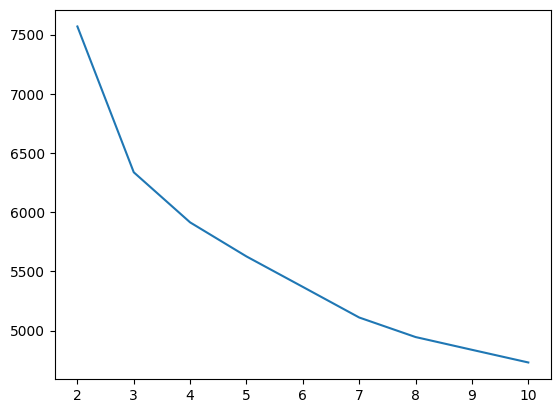

In [ ]:
import matplotlib.pyplot as plt
plt.plot(range(2,11), wcss)

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

# Assuming an optimal k (e.g., 3) is chosen based on the elbow method
k_optimal = 3 # You can change this based on your elbow plot

kmeans_optimal = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_optimal.fit(df_clustering)

# X should be your data for clustering, which is df_clustering
X = df_clustering
# labels should be the cluster assignments from the fitted KMeans model
labels = kmeans_optimal.labels_

score = silhouette_score(X, labels)

In [ ]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df_clustering['Cluster'] = kmeans.fit_predict(X)

In [ ]:
from scipy.cluster.hierarchy import linkage, dendrogram

In [ ]:
linked = linkage(X, method='ward')

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [5.0, 5.0, 20.0, 20.0],
  [45.0, 45.0, 55.0, 55.0],
  [35.0, 35.0, 50.0, 50.0],
  [75.0, 75.0, 85.0, 85.0],
  [95.0, 95.0, 105.0, 105.0],
  [80.0, 80.0, 100.0, 100.0],
  [65.0, 65.0, 90.0, 90.0],
  [42.5, 42.5, 77.5, 77.5],
  [12.5, 12.5, 60.0, 60.0],
  [125.0, 125.0, 135.0, 135.0],
  [115.0, 115.0, 130.0, 130.0],
  [145.0, 145.0, 155.0, 155.0],
  [165.0, 165.0, 175.0, 175.0],
  [150.0, 150.0, 170.0, 170.0],
  [195.0, 195.0, 205.0, 205.0],
  [185.0, 185.0, 200.0, 200.0],
  [235.0, 235.0, 245.0, 245.0],
  [225.0, 225.0, 240.0, 240.0],
  [215.0, 215.0, 232.5, 232.5],
  [192.5, 192.5, 223.75, 223.75],
  [160.0, 160.0, 208.125, 208.125],
  [122.5, 122.5, 184.0625, 184.0625],
  [36.25, 36.25, 153.28125, 153.28125],
  [275.0, 275.0, 285.0, 285.0],
  [265.0, 265.0, 280.0, 280.0],
  [255.0, 255.0, 272.5, 272.5],
  [295.0, 295.0, 305.0, 305.0],
  [335.0, 335.0, 345.0, 345.0],
  [325.0, 325.0, 340.0, 340.0],
  [315.0, 315.0, 332.5, 332.5],
  [300.0, 300.0,

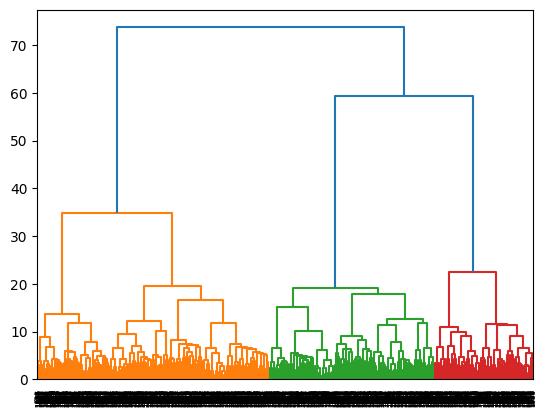

In [ ]:
dendrogram(linked)

In [ ]:
cluster_summary = df_clustering.groupby('Cluster').mean()

In [ ]:
!pip install streamlit
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py


In [ ]:
df_clustering.groupby('Cluster').describe()

satisfaction score                                                    \
                     count      mean       std       min       25%       50%   
Cluster                                                                        
0                    291.0 -0.750015  0.582802 -1.435740 -1.435740 -0.728130   
1                    653.0 -0.731381  0.588507 -1.435740 -1.435740 -0.728130   
2                    660.0  1.038749  0.354067  0.687089  0.687089  0.687089   
3                    396.0  0.025939  0.964783 -1.435740 -0.728130 -0.020521   

                            loan applied            ...              age  \
              75%       max        count      mean  ...  75%  max  count   
Cluster                                             ...                    
0       -0.020521 -0.020521        291.0  0.340206  ...  1.0  1.0  291.0   
1       -0.020521 -0.020521        653.0  0.376723  ...  1.0  1.0  653.0   
2        1.394698  1.394698        660.0  0.375758  ...  1.0  1.0  660.0   
3        0.687089  1.394698        396.0  0.361111  ...  1.0  1.0  396.0   

                                                                               
             mean       std       min       25%       50%       75%       max  
Cluster                                                                        
0        0.431571  0.449387 -0.285903  0.102741  0.380344  0.741227  1.601796  
1        0.462179  0.476114 -0.285903  0.047220  0.435864  0.824508  1.629556  
2        0.439692  0.476668 -0.285903  0.040280  0.408104  0.803688  1.435234  
3       -1.812087  0.237553 -2.173602 -2.007040 -1.812718 -1.618396 -1.201992  

[4 rows x 24 columns]

In [ ]:
import pandas as pd
import plotly.express as px

df = pd.read_csv("clients.csv")

fig = px.pie(
    df,
    names='client type',
    title='Buyer Distribution'
)

fig.show()